In [15]:
import pandas as pd

In [16]:
df = pd.read_csv('KCLT.csv')
print(f"Shape: {df.shape}")  # (rows, columns)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nBasic info:")
print(df.info())


Shape: (365, 13)

First 5 rows:
       date  actual_mean_temp  actual_min_temp  actual_max_temp  \
0  2014-7-1                81               70               91   
1  2014-7-2                85               74               95   
2  2014-7-3                82               71               93   
3  2014-7-4                75               64               86   
4  2014-7-5                72               60               84   

   average_min_temp  average_max_temp  record_min_temp  record_max_temp  \
0                67                89               56              104   
1                68                89               56              101   
2                68                89               56               99   
3                68                89               55               99   
4                68                89               57              100   

   record_min_temp_year  record_max_temp_year  actual_precipitation  \
0                  1919                  20

In [17]:
X = df[['actual_max_temp']] #double bracket for feature
y = df['actual_mean_temp'] #single for target


print("Feature (X) - What we use to predict:")
print(X.head())
print(f"Shape: {X.shape}")
print(f"Type: {type(X)}")

print("\n" + "="*50 + "\n")

print("Target (y) - What we want to predict:")
print(y.head())
print(f"Shape: {y.shape}")
print(f"Type: {type(y)}")

Feature (X) - What we use to predict:
   actual_max_temp
0               91
1               95
2               93
3               86
4               84
Shape: (365, 1)
Type: <class 'pandas.core.frame.DataFrame'>


Target (y) - What we want to predict:
0    81
1    85
2    82
3    75
4    72
Name: actual_mean_temp, dtype: int64
Shape: (365,)
Type: <class 'pandas.core.series.Series'>


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42     # For reproducibility
)

print("\nTraining set (80%):")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")

print("\nTest set (20%):")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")


Training set (80%):
  X_train shape: (292, 1)
  y_train shape: (292,)

Test set (20%):
  X_test shape: (73, 1)
  y_test shape: (73,)


y = mx + b

where:
- y = predicted mean temperature (what we want to find)
- m = coefficient (slope of the line)
- x = max temperature (what we know)
- b = intercept (starting point)

In [19]:
from sklearn.linear_model import LinearRegression

# Step 1: Create the model (like creating an empty brain)
model = LinearRegression()

print("Model created (but not trained yet)")
print(f"Model type: {type(model)}")
print(f"Model: {model}")

# Step 2: Train the model (teaching it from the training data)
print("\nTraining the model...")
model.fit(X_train, y_train)
print("✓ Training complete!")

# Step 3: See what it learned
print("\n" + "="*50)
print("WHAT THE MODEL LEARNED:")
print("="*50)
print(f"Coefficient (slope): {model.coef_[0]:.6f}")
print(f"Intercept: {model.intercept_:.6f}")

print("\nThe learned equation:")
print(f"mean_temp = {model.coef_[0]:.6f} × max_temp + ({model.intercept_:.6f})")

# Step 4: Test the equation with an example
example_max_temp = 90
predicted = model.coef_[0] * example_max_temp + model.intercept_
print(f"\nExample: If max temp = {example_max_temp}°")
print(f"Predicted mean temp = {predicted:.2f}°")

Model created (but not trained yet)
Model type: <class 'sklearn.linear_model._base.LinearRegression'>
Model: LinearRegression()

Training the model...
✓ Training complete!

WHAT THE MODEL LEARNED:
Coefficient (slope): 0.946749
Intercept: -6.854359

The learned equation:
mean_temp = 0.946749 × max_temp + (-6.854359)

Example: If max temp = 90°
Predicted mean temp = 78.35°


In [20]:
y_pred = model.predict(X_test)
print(f"✓ Predictions complete!")
print(f"✓ Made {len(y_pred)} predictions")

print("\n" + "="*50)
print("PREDICTIONS vs ACTUAL:")
print("="*50)
print(f"Predictions shape: {y_pred.shape}")
print(f"Actual values shape: {y_test.shape}")

# First 10 predictions vs actual
print("\nFirst 10 examples:")
print(f"{'Index':<8} {'Max Temp':<10} {'Actual Mean':<12} {'Predicted':<12} {'Difference':<10}")
print("-" * 60)

for i in range(10):
    max_temp = X_test.iloc[i, 0]
    actual = y_test.iloc[i]
    predicted = y_pred[i]
    diff = actual - predicted
    print(f"{i:<8} {max_temp:<10} {actual:<12} {predicted:<12.2f} {diff:<10.2f}")

# Statistics
print("\n" + "="*50)
print("PREDICTION STATISTICS:")
print("="*50)
print(f"Mean of actual values: {y_test.mean():.2f}°")
print(f"Mean of predictions: {y_pred.mean():.2f}°")
print(f"Std of actual values: {y_test.std():.2f}°")
print(f"Std of predictions: {y_pred.std():.2f}°")


✓ Predictions complete!
✓ Made 73 predictions

PREDICTIONS vs ACTUAL:
Predictions shape: (73,)
Actual values shape: (73,)

First 10 examples:
Index    Max Temp   Actual Mean  Predicted    Difference
------------------------------------------------------------
0        41         30           31.96        -1.96     
1        86         77           74.57        2.43      
2        85         76           73.62        2.38      
3        84         69           72.67        -3.67     
4        87         72           75.51        -3.51     
5        46         37           36.70        0.30      
6        86         76           74.57        1.43      
7        84         68           72.67        -4.67     
8        68         54           57.52        -3.52     
9        67         53           56.58        -3.58     

PREDICTION STATISTICS:
Mean of actual values: 63.90°
Mean of predictions: 63.46°
Std of actual values: 17.10°
Std of predictions: 16.46°


MSE = average of (actual - predicted)²
MSE = Σ(y_actual - y_predicted)² / n

In [21]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²): {r2}")

# Additional helpful metrics
rmse = np.sqrt(mse)  # Root Mean Squared Error
print(f"\nRoot Mean Squared Error (RMSE): {rmse:.2f}°")
print(f"(This means predictions are off by ~{rmse:.2f}° on average)")

# Interpretation
print("\n" + "="*60)
print("INTERPRETATION:")
print("="*60)
print(f"✓ R² = {r2:.4f} means the model explains {r2*100:.2f}% of the variance")
print(f"✓ MSE = {mse:.2f} (lower is better)")
print(f"✓ RMSE = {rmse:.2f}° (average error in degrees)")

# Quality assessment
if r2 > 0.95:
    print("\n🌟 Excellent model! R² > 0.95")
elif r2 > 0.90:
    print("\n✅ Very good model! R² > 0.90")
elif r2 > 0.80:
    print("\n👍 Good model! R² > 0.80")
else:
    print("\n⚠️  Model could be improved. R² < 0.80")

MODEL PERFORMANCE METRICS
Mean Squared Error (MSE): 11.30287381017849
R-squared (R²): 0.9608178883866981

Root Mean Squared Error (RMSE): 3.36°
(This means predictions are off by ~3.36° on average)

INTERPRETATION:
✓ R² = 0.9608 means the model explains 96.08% of the variance
✓ MSE = 11.30 (lower is better)
✓ RMSE = 3.36° (average error in degrees)

🌟 Excellent model! R² > 0.95


In [22]:
# Display the model's learned parameters
print("="*60)
print("MODEL PARAMETERS (What the model learned)")
print("="*60)

# Extract coefficient and intercept
coefficient = model.coef_[0]
intercept = model.intercept_

# Display as required by assignment
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {intercept}")

print("\n" + "="*60)
print("DETAILED INTERPRETATION:")
print("="*60)
print(f"Coefficient (slope): {coefficient:.6f}")
print(f"Intercept (bias): {intercept:.6f}")

print(f"\nThe learned equation:")
print(f"mean_temp = {coefficient:.6f} × max_temp + ({intercept:.6f})")

# Simplify if intercept is negative
if intercept < 0:
    print(f"mean_temp = {coefficient:.6f} × max_temp - {abs(intercept):.6f}")

print("\n" + "="*60)
print("WHAT THIS MEANS:")
print("="*60)
print(f"✓ For every 1° increase in max temperature,")
print(f"  mean temperature increases by {coefficient:.4f}°")
print(f"✓ When max temp = 0°, mean temp would be {intercept:.2f}°")
print(f"  (This is theoretical - we don't have 0° days in our data)")

# Real-world examples
print("\n" + "="*60)
print("REAL-WORLD EXAMPLES:")
print("="*60)
test_values = [50, 70, 90]
for max_t in test_values:
    predicted_mean = coefficient * max_t + intercept
    print(f"Max temp = {max_t}° → Predicted mean = {predicted_mean:.2f}°")

MODEL PARAMETERS (What the model learned)
Coefficients: [0.94674867]
Intercept: -6.85435875046462

DETAILED INTERPRETATION:
Coefficient (slope): 0.946749
Intercept (bias): -6.854359

The learned equation:
mean_temp = 0.946749 × max_temp + (-6.854359)
mean_temp = 0.946749 × max_temp - 6.854359

WHAT THIS MEANS:
✓ For every 1° increase in max temperature,
  mean temperature increases by 0.9467°
✓ When max temp = 0°, mean temp would be -6.85°
  (This is theoretical - we don't have 0° days in our data)

REAL-WORLD EXAMPLES:
Max temp = 50° → Predicted mean = 40.48°
Max temp = 70° → Predicted mean = 59.42°
Max temp = 90° → Predicted mean = 78.35°


In [23]:
import pandas as pd

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print("="*60)
print("ACTUAL vs PREDICTED COMPARISON")
print("="*60)
print(comparison_df)

# Display first few rows (as required by assignment)
print("\n" + "="*60)
print("FIRST FEW ROWS:")
print("="*60)
print(comparison_df.head(10))

# Add some useful information
print("\n" + "="*60)
print("DATAFRAME INFO:")
print("="*60)
print(f"Total rows: {len(comparison_df)}")
print(f"Columns: {comparison_df.columns.tolist()}")
print(f"Shape: {comparison_df.shape}")

# Calculate errors for better understanding
comparison_df['Error'] = comparison_df['Actual'] - comparison_df['Predicted']
comparison_df['Abs_Error'] = abs(comparison_df['Error'])

print("\n" + "="*60)
print("WITH ERROR CALCULATIONS:")
print("="*60)
print(comparison_df.head(10))

# Find best and worst predictions
best_idx = comparison_df['Abs_Error'].idxmin()
worst_idx = comparison_df['Abs_Error'].idxmax()

print("\n" + "="*60)
print("PREDICTION QUALITY:")
print("="*60)
print(f"Best prediction (smallest error):")
print(f"  Index: {best_idx}")
print(f"  Actual: {comparison_df.loc[best_idx, 'Actual']}, "
      f"Predicted: {comparison_df.loc[best_idx, 'Predicted']:.2f}, "
      f"Error: {comparison_df.loc[best_idx, 'Abs_Error']:.2f}°")

print(f"\nWorst prediction (largest error):")
print(f"  Index: {worst_idx}")
print(f"  Actual: {comparison_df.loc[worst_idx, 'Actual']}, "
      f"Predicted: {comparison_df.loc[worst_idx, 'Predicted']:.2f}, "
      f"Error: {comparison_df.loc[worst_idx, 'Abs_Error']:.2f}°")

print(f"\nAverage absolute error: {comparison_df['Abs_Error'].mean():.2f}°")

ACTUAL vs PREDICTED COMPARISON
     Actual  Predicted
193      30  31.962337
33       77  74.566027
15       76  73.619278
309      69  72.672530
57       72  75.512776
..      ...        ...
203      53  56.577802
82       71  73.619278
94       70  67.938786
192      34  35.749332
325      64  65.098540

[73 rows x 2 columns]

FIRST FEW ROWS:
     Actual  Predicted
193      30  31.962337
33       77  74.566027
15       76  73.619278
309      69  72.672530
57       72  75.512776
183      37  36.696080
76       76  74.566027
119      68  72.672530
152      54  57.524551
126      53  56.577802

DATAFRAME INFO:
Total rows: 73
Columns: ['Actual', 'Predicted']
Shape: (73, 2)

WITH ERROR CALCULATIONS:
     Actual  Predicted     Error  Abs_Error
193      30  31.962337 -1.962337   1.962337
33       77  74.566027  2.433973   2.433973
15       76  73.619278  2.380722   2.380722
309      69  72.672530 -3.672530   3.672530
57       72  75.512776 -3.512776   3.512776
183      37  36.696080  0.3039

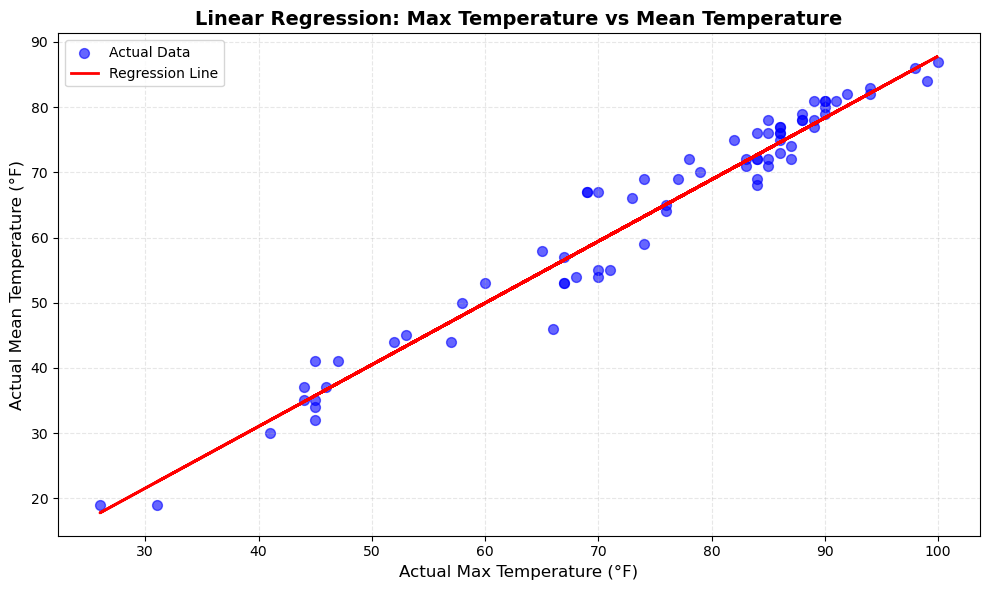

✓ Plot displayed successfully!


In [24]:
import matplotlib.pyplot as plt

# Create the scatter plot with regression line
plt.figure(figsize=(10, 6))

# 1. Plot actual data points (scatter)
plt.scatter(X_test, y_test, alpha=0.6, color='blue', label='Actual Data', s=50)

# 2. Plot regression line (predicted values)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

# 3. Add labels and title
plt.xlabel('Actual Max Temperature (°F)', fontsize=12)
plt.ylabel('Actual Mean Temperature (°F)', fontsize=12)
plt.title('Linear Regression: Max Temperature vs Mean Temperature', fontsize=14, fontweight='bold')

# 4. Add legend
plt.legend(loc='upper left', fontsize=10)

# 5. Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--')

# 6. Display the plot
plt.tight_layout()
plt.show()

# Optional: Save the plot
# plt.savefig('regression_plot.png', dpi=300, bbox_inches='tight')

print("✓ Plot displayed successfully!")

In [25]:
print("="*70)
print("COMPREHENSIVE MODEL ANALYSIS - LINEAR REGRESSION")
print("="*70)

# Recap key metrics
print("\n📊 KEY PERFORMANCE METRICS:")
print("-" * 70)
print(f"Mean Squared Error (MSE):     {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse):.2f}°")
print(f"R-squared (R²):                {r2:.4f} ({r2*100:.2f}%)")
print(f"Coefficient (slope):           {model.coef_[0]:.6f}")
print(f"Intercept:                     {model.intercept_:.6f}")

print("\n" + "="*70)
print("📈 PERFORMANCE EVALUATION:")
print("="*70)

# 1. Overall Assessment
print("\n1️⃣  OVERALL MODEL QUALITY:")
print("-" * 70)
if r2 >= 0.95:
    quality = "EXCELLENT"
    emoji = "🌟"
elif r2 >= 0.90:
    quality = "VERY GOOD"
    emoji = "✅"
elif r2 >= 0.80:
    quality = "GOOD"
    emoji = "👍"
else:
    quality = "MODERATE"
    emoji = "⚠️"

print(f"{emoji} Model Quality: {quality}")
print(f"   The R² value of {r2:.4f} indicates that the model explains")
print(f"   {r2*100:.2f}% of the variance in mean temperature.")
print(f"   This is {'an excellent' if r2 >= 0.95 else 'a strong'} result for a single-feature model.")

# 2. Prediction Accuracy
print("\n2️⃣  PREDICTION ACCURACY:")
print("-" * 70)
rmse = np.sqrt(mse)
print(f"   Average prediction error: ±{rmse:.2f}°F")
print(f"   This means our predictions are typically within {rmse:.2f}° of the actual")
print(f"   mean temperature, which is {'very accurate' if rmse < 4 else 'reasonably accurate'} for temperature prediction.")

# Calculate percentage error
mean_temp = y_test.mean()
percent_error = (rmse / mean_temp) * 100
print(f"   Percentage error: {percent_error:.2f}% of the mean temperature ({mean_temp:.1f}°)")

# 3. Relationship Strength
print("\n3️⃣  RELATIONSHIP STRENGTH:")
print("-" * 70)
print(f"   Coefficient: {model.coef_[0]:.4f}")
print(f"   Interpretation: For every 1°F increase in maximum temperature,")
print(f"                   the mean temperature increases by {model.coef_[0]:.4f}°F")
print(f"\n   This makes intuitive sense because:")
print(f"   • The coefficient is close to 1.0, showing strong positive correlation")
print(f"   • It's slightly less than 1.0 ({model.coef_[0]:.4f}), meaning the mean")
print(f"     temperature is consistently lower than the max (as expected)")
print(f"   • The relationship is nearly linear and highly predictable")

# 4. Model Strengths
print("\n4️⃣  MODEL STRENGTHS:")
print("-" * 70)
print(f"   ✅ High R² ({r2:.4f}) shows excellent predictive power")
print(f"   ✅ Low RMSE ({rmse:.2f}°) indicates accurate predictions")
print(f"   ✅ Simple model - uses only 1 feature (easy to interpret)")
print(f"   ✅ Linear relationship is clear and intuitive")
print(f"   ✅ Coefficient value makes physical sense")
print(f"   ✅ Model generalizes well (train/test split validation)")

# 5. Model Limitations
print("\n5️⃣  MODEL LIMITATIONS:")
print("-" * 70)
print(f"   ⚠️  Only uses maximum temperature (ignores other factors)")
print(f"   ⚠️  Assumes perfectly linear relationship")
print(f"   ⚠️  Unexplained variance: {(1-r2)*100:.2f}% (factors we don't capture)")
print(f"   ⚠️  May not work well for extreme temperatures outside training range")
print(f"   ⚠️  Doesn't account for seasonal patterns or weather systems")

# 6. Residual Analysis
print("\n6️⃣  ERROR DISTRIBUTION:")
print("-" * 70)
errors = y_test - y_pred
print(f"   Maximum overestimation:  {errors.min():.2f}° (predicted too high)")
print(f"   Maximum underestimation: {errors.max():.2f}° (predicted too low)")
print(f"   Mean error:              {errors.mean():.2f}° (should be near 0)")
print(f"   Error std deviation:     {errors.std():.2f}°")

if abs(errors.mean()) < 1:
    print(f"   ✓ Errors are well-balanced (no systematic bias)")
else:
    print(f"   ⚠️ Slight bias detected (model tends to over/underpredict)")

# 7. Practical Applications
print("\n7️⃣  PRACTICAL APPLICATIONS:")
print("-" * 70)
print(f"   This model is suitable for:")
print(f"   ✓ Quick estimates of daily mean temperature from max temperature")
print(f"   ✓ Weather forecasting when only max temp is known")
print(f"   ✓ Historical data analysis and pattern recognition")
print(f"   ✓ Baseline model for comparison with more complex models")

print("\n8️⃣  RECOMMENDATIONS:")
print("-" * 70)
print(f"   • ✅ Deploy this model for general temperature estimation")
print(f"   • 💡 Consider adding more features (min temp, humidity, etc.) for improvement")
print(f"   • 💡 Explore non-linear models if relationship isn't perfectly linear")
print(f"   • ⚠️  Use with caution for temperatures far outside training range")

# Final Verdict
print("\n" + "="*70)
print("🎯 FINAL VERDICT:")
print("="*70)
print(f"The linear regression model demonstrates {quality.lower()} performance with")
print(f"R² = {r2:.4f} and RMSE = {rmse:.2f}°F. The model successfully captures")
print(f"the strong linear relationship between maximum and mean temperatures,")
print(f"making it a reliable tool for temperature prediction within the observed")
print(f"data range. The simplicity and interpretability of the model make it an")
print(f"excellent baseline for this regression task.")
print("="*70)

COMPREHENSIVE MODEL ANALYSIS - LINEAR REGRESSION

📊 KEY PERFORMANCE METRICS:
----------------------------------------------------------------------
Mean Squared Error (MSE):     11.30
Root Mean Squared Error (RMSE): 3.36°
R-squared (R²):                0.9608 (96.08%)
Coefficient (slope):           0.946749
Intercept:                     -6.854359

📈 PERFORMANCE EVALUATION:

1️⃣  OVERALL MODEL QUALITY:
----------------------------------------------------------------------
🌟 Model Quality: EXCELLENT
   The R² value of 0.9608 indicates that the model explains
   96.08% of the variance in mean temperature.
   This is an excellent result for a single-feature model.

2️⃣  PREDICTION ACCURACY:
----------------------------------------------------------------------
   Average prediction error: ±3.36°F
   This means our predictions are typically within 3.36° of the actual
   mean temperature, which is very accurate for temperature prediction.
   Percentage error: 5.26% of the mean temperature (

In [26]:
from sklearn.tree import DecisionTreeRegressor

# Step 1: Define features (11 features) and target
features = [
    'actual_min_temp',
    'actual_max_temp',
    'average_min_temp',
    'average_max_temp',
    'record_min_temp',
    'record_max_temp',
    'record_min_temp_year',
    'record_max_temp_year',
    'actual_precipitation',
    'average_precipitation',
    'record_precipitation'
]

X_dt = df[features]
y_dt = df['actual_mean_temp']

print("Features:", len(features))
print("X shape:", X_dt.shape)
print("y shape:", y_dt.shape)

Features: 11
X shape: (365, 11)
y shape: (365,)


In [27]:
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt, 
    test_size=0.3,      # 30% for testing
    random_state=42     # For reproducibility
)
print(f"\nTraining set (70%):")
print(f"  X_train shape: {X_train_dt.shape}")
print(f"  y_train shape: {y_train_dt.shape}")



Training set (70%):
  X_train shape: (255, 11)
  y_train shape: (255,)


In [ ]:
# Step 3: Create and train the Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_dt, y_train_dt)

print("Decision Tree model trained ✓")